uni_section_v12: command_v12.md 반영 — §1 프루닝 정상화 + Cascade Stop-Snap-Resume
  [§1] 결정론 게이트(물리) / feas_gate 제거 / Aug-Lagrangian 질량 / protect={0,1,2} / 3단계
  [§2~4] z<0.1 20ep 연속 트리거 → 그래프 수술(Y-Snap+차원축소) → warm-start 하드 재시작
[gradcheck] dMp/dt OK -- autograd=1.3173e+07, FD=1.3160e+07, rel_err=9.88e-04

[Cycle 0] Training | n_parts=5 | protect=(0, 1, 2) | prunable=[3, 4]
  target_area=1157.3 | trigger: z<0.1 for 20 ep | cooldown=30
Ep || Loss | MpErr%(s/e) | Area(s/e) | Coll || St|tG|β|λs|μm | z_cont
0000 || 5.363 | 47.2/39.9 |   1163/  1221 | 0.000 || 1|0.00|0.70|0.00|0.0 | [1.00 1.00 1.00 0.96 0.96]
0019 || 3.930 | 22.0/21.4 |   1274/  1280 | 0.000 || 1|0.00|0.70|0.00|0.0 | [1.00 1.00 1.00 0.96 0.96]
0039 || 3.243 |  3.5/ 5.4 |   1515/  1477 | 0.008 || 1|0.00|0.70|0.00|0.0 | [1.00 1.00 1.00 0.96 0.96]
0059 || 2.747 | 16.7/ 9.4 |   1378/  1411 | 0.000 || 1|0.00|0.70|0.00|0.5 | [1.00 1.00 1.00 0.96 0.96]
0079 || 1.847 |  4.0/ 1.6 |   1573/  1548 | 0.007 || 1|0.00|0.70|0.00|0.5 | [1.00 1.00

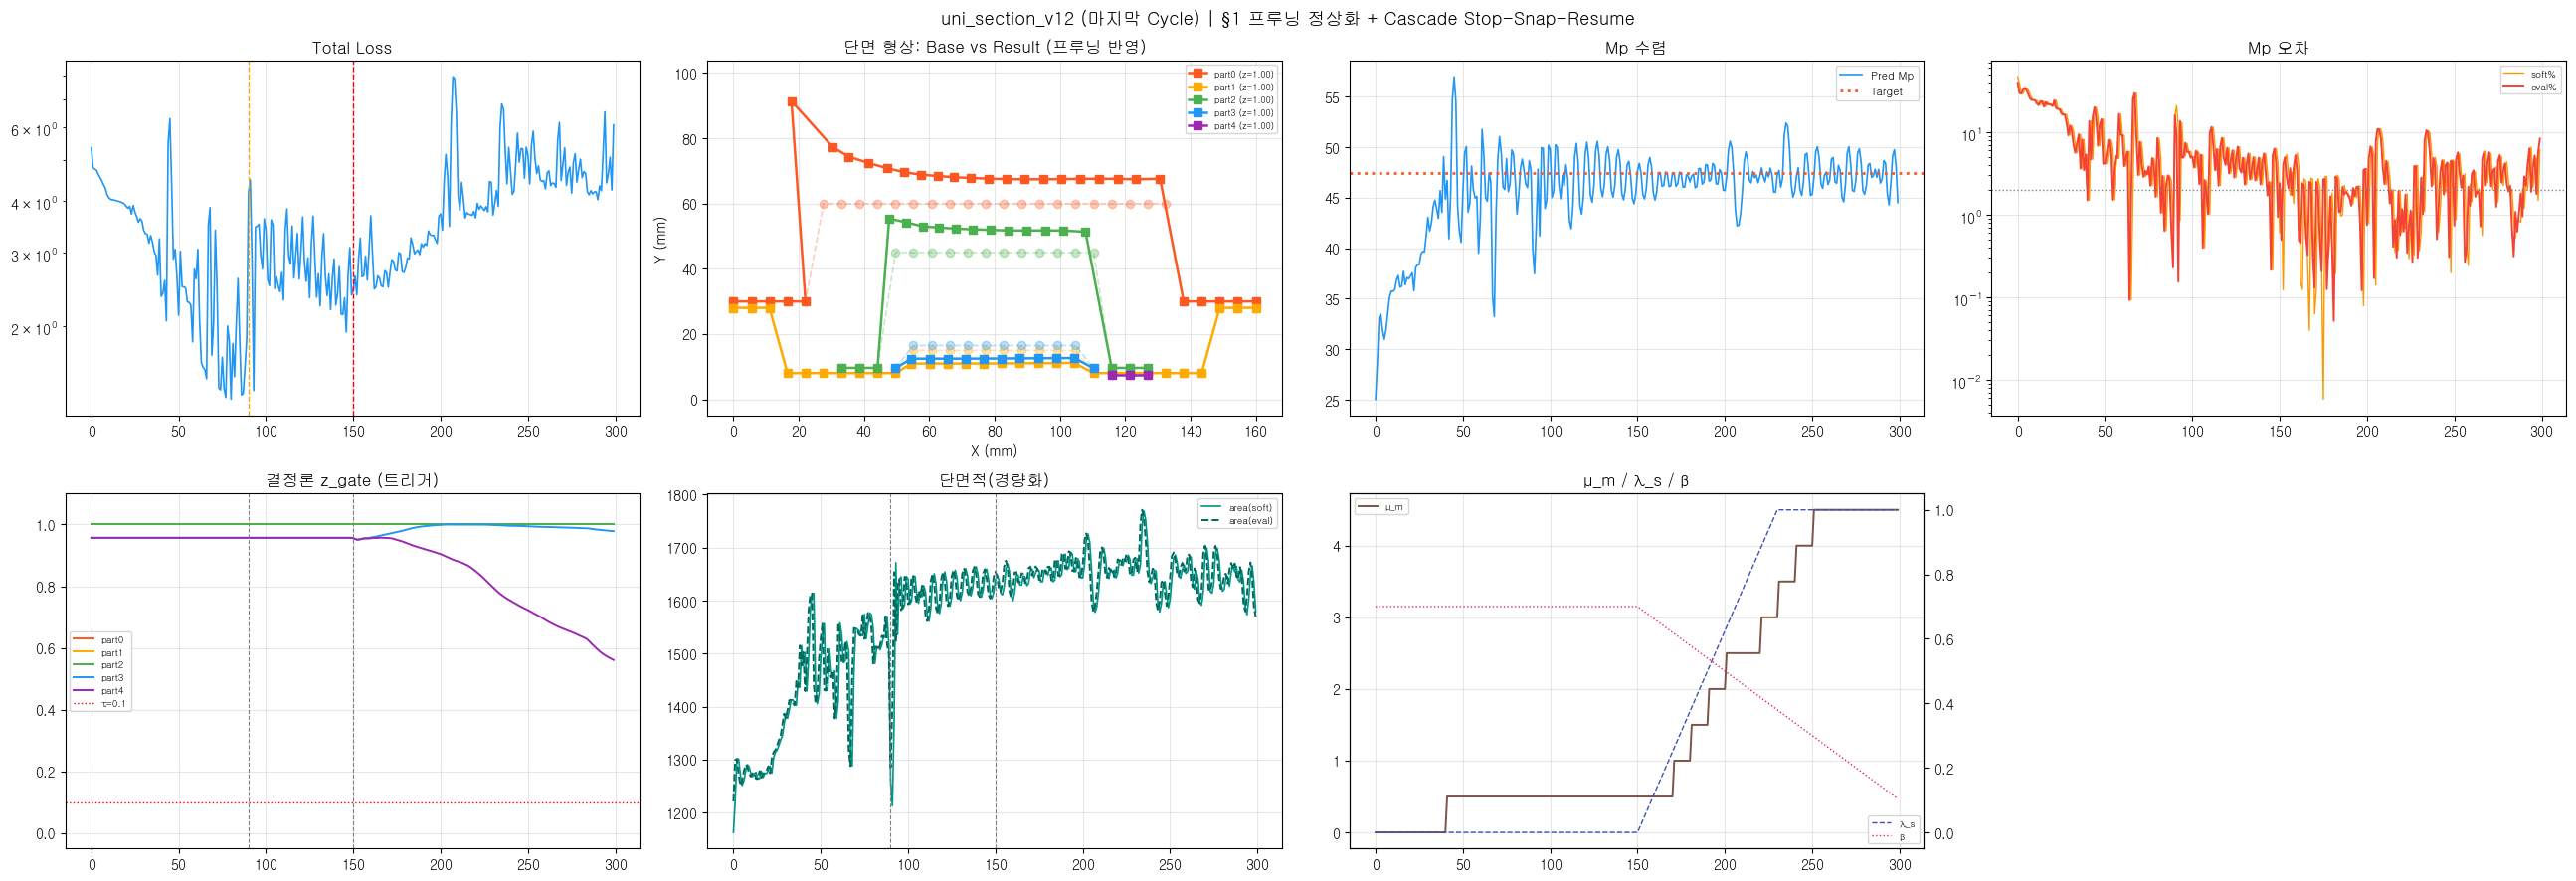


결과 저장: c:\Users\user\Documents\GitHub\hmc_mlv\01. CGNN\uni-section\code\uni_section_v12_result.png

최종 결과 (마지막 Cycle)
  ★ 최경량 Feasible: epoch 89, MpErr(eval)=0.23%, area(eval)=1499.1 mm², 잔여파트 게이트 제거=없음
  Cascade 총 1 Cycle 수행. 최종 파트 수: 5


In [2]:
 #!/usr/bin/env python
# coding: utf-8

"""
uni_section_v12.py
─────────────────────────────────────
command_v12.md 반영: uni_section_v11.py의 부재 프루닝 실패를 교정(§1)하고,
그 위에 Cascade "Stop-Snap-Resume"(§2~§4) 위상 경량화 파이프라인을 얹은 버전.
설계 근거: docs/command/command_v12.md, docs/idea/idea_v12.md, docs/idea/idea_v1.md
(Synod idea/review/design 세션 실 병렬 교차검증).

── §1 v11 프루닝 학습 정상화 (선결) ──────────────────────────────
  [1.1] 물리(Mp/면적/충돌)엔 결정론적 게이트 z_gate (stochastic 샘플 미주입 → variance trap 제거).
        희소화는 z_open=P(gate active)에 부과.
  [1.2] feas_gate 데드락 제거. 질량=Augmented-Lagrangian: μ_m·relu(area/target-1) + w_area·(area/area_init).
        phys는 asymmetric_huber(강건) + w_phys=30. 희소화는 후보 파트만.
  [1.3] init_log_alpha=2.0, part_gate 전용 optimizer 그룹 lr=1e-2 wd=0, log_alpha clamp[-8,8], β 어닐링.
        Stage1·2 게이트 동결(z=1), Stage3만 활성(gate_active).
        3단계: 형상[0,90) / 두께언락[90,150) / 프루닝[150,).

── §2~§4 Cascade Stop-Snap-Resume ────────────────────────────────
  [§3.1] Cycle1: 프루닝 학습. TRIGGER: 후보 파트 i의 eval z_i<τ=0.1이 20 epoch 연속 → BREAK, 삭제 확정.
         이벤트당 1개(최저 z)만 삭제. 수술 후 cooldown 30 epoch.
  [§2]   perform_graph_surgery: Y-Snap(삭제 전) → 노드/엣지 삭제·재색인 → part_id 0..K-1 연속화
         → build_collision_spec 재빌드 준비 → protect 재매핑.
  [§3.3] Cycle2 Hard Restart: CGDN(n_parts=new) 재인스턴스화, optimizer/epoch/curriculum/μ_m/β 전부 리셋.
         WARM-START: 백본·디코더 가중치 직접 이식, part_gate.log_alpha는 생존 매핑으로 이식(형상 이력 보존).
  [§4]   run_cascade_training: run_training을 감싸는 아우터 루프(max_cycles=3), 수술 전후 체크포인트.

v10/v11 유지: CGDN 백본, native autograd Mp, collision v5 기하, mesh order, 비대칭 Huber, 커리큘럼.
"""

import math
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'

from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# SECTION 0: Mp 계산 — native autograd
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]
    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)
    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v); y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0; y_bot = y_min - t_y / 2.0
    H = torch.clamp(y_top - y_bot, min=1e-12)
    Area_fy = L * t_e * fy_e
    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)
    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))
    return mp_total, y_pna


def calculate_mpl(coords, t, fy, edge_index):
    return compute_edge_mp_pna(coords, t, fy, edge_index)[0]


def verify_thickness_gradient(coords, t, fy, edge_index, eps=1e-4):
    """[v10 §3.1] 학습 전 ∂Mp/∂t 유한차분 검증 (raw t 직접, 게이트 무관)."""
    coords = coords.detach(); fy = fy.detach()
    t_leaf = t.detach().clone().requires_grad_(True)
    mp, _ = compute_edge_mp_pna(coords, t_leaf, fy, edge_index)
    mp.backward()
    if t_leaf.grad is None:
        raise RuntimeError("[gradcheck] dMp/dt None!")
    grad_sum = t_leaf.grad.sum().item()
    with torch.no_grad():
        mp_p, _ = compute_edge_mp_pna(coords, t + eps, fy, edge_index)
        mp_m, _ = compute_edge_mp_pna(coords, t - eps, fy, edge_index)
    fd = (mp_p.item() - mp_m.item()) / (2.0 * eps)
    rel_err = abs(fd - grad_sum) / (abs(fd) + 1e-8)
    if fd <= 0:
        raise RuntimeError(f"[gradcheck] dMp/dt={fd:.4e}<=0")
    if rel_err > 1e-3:
        raise RuntimeError(f"[gradcheck] rel_err {rel_err:.2e} > 1e-3")
    print(f"[gradcheck] dMp/dt OK -- autograd={grad_sum:.4e}, FD={fd:.4e}, rel_err={rel_err:.2e}")
    return grad_sum, fd, rel_err


# ══════════════════════════════════════════════════════════════════
# SECTION 0b: [§1.1] Hard-Concrete 게이트 — 결정론 물리 / 확률 L0 분리
# ══════════════════════════════════════════════════════════════════

class HardConcreteGate(nn.Module):
    gamma = -0.1
    zeta  = 1.1
    LOG_ALPHA_MIN, LOG_ALPHA_MAX = -8.0, 8.0

    def __init__(self, n_parts=5, protect_indices=(0, 1, 2), init_log_alpha=2.0):
        super().__init__()
        self.n_parts = n_parts
        protected = torch.zeros(n_parts, dtype=torch.bool)
        if protect_indices:
            for p in protect_indices:
                if 0 <= p < n_parts:
                    protected[p] = True
        self.register_buffer('protected_mask', protected)
        self.register_buffer('keep_mask', (~protected).float())
        self.log_alpha = nn.Parameter(torch.full((n_parts,), float(init_log_alpha)))

    def forward(self, beta=0.7):
        la = self.log_alpha
        keep = self.keep_mask
        s = torch.sigmoid(la)
        z_gate = torch.clamp(s * (self.zeta - self.gamma) + self.gamma, 0.0, 1.0)
        z_gate = z_gate * keep + (1.0 - keep)
        const = beta * math.log(-self.gamma / self.zeta)
        z_open = torch.sigmoid(la - const)
        z_open = z_open * keep + (1.0 - keep)
        return z_gate, z_open

    @torch.no_grad()
    def clamp_(self):
        self.log_alpha.clamp_(self.LOG_ALPHA_MIN, self.LOG_ALPHA_MAX)

    @torch.no_grad()
    def eval_gate(self, tau=0.5):
        z_gate, _ = self.forward(beta=0.1)
        return (z_gate >= tau).float() * self.keep_mask + (1.0 - self.keep_mask)

    @torch.no_grad()
    def eval_z(self):
        """결정론 z_gate 실수값 (트리거 z_i<0.1 판정용)."""
        return self.forward(beta=0.1)[0]


# ══════════════════════════════════════════════════════════════════
# SECTION 0c: CGDN 백본 (파트 수 독립적 백본 + 파트 존재 게이트)
# ══════════════════════════════════════════════════════════════════

class FiLMGenerator(nn.Module):
    MP_SCALE = 1e6
    def __init__(self, hidden_channels):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 64), nn.GELU(), nn.Linear(64, hidden_channels * 2))
        nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)
    def forward(self, target_mp):
        out = self.net(target_mp / self.MP_SCALE)
        dg, beta = torch.chunk(out, 2, dim=-1)
        return 1.0 + dg, beta


class CGDNBlock(nn.Module):
    def __init__(self, hidden_channels, heads=4, edge_dim=4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(hidden_channels, hidden_channels // heads, heads=heads, edge_dim=edge_dim, concat=True)
        self.norm = LayerNorm(hidden_channels)
    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h); h = gamma * h + beta; h = F.gelu(h)
        return h + h_res


class CGDN(nn.Module):
    """백본·디코더는 파트 수와 무관(노드 단위). part_gate만 n_parts 의존 → warm-start 용이."""
    DELTA_SCALE = 1.35
    T_MIN = 0.1
    T_MAX = 2.5

    def __init__(self, in_channels=8, hidden_channels=128, num_layers=4, heads=4,
                 edge_dim=4, max_displacement=50.0, n_parts=5, protect_indices=(0, 1, 2)):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers
        self.n_parts = n_parts
        self.node_encoder = nn.Sequential(nn.Linear(in_channels, hidden_channels), LayerNorm(hidden_channels), nn.GELU())
        self.film_generators = nn.ModuleList([FiLMGenerator(hidden_channels) for _ in range(num_layers)])
        self.blocks = nn.ModuleList([CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim) for _ in range(num_layers)])
        self.coord_decoder = nn.Sequential(nn.Linear(hidden_channels, 64), nn.GELU(), nn.Linear(64, 2))
        self.thickness_decoder = nn.Sequential(nn.Linear(hidden_channels, 32), nn.GELU(), nn.Linear(32, 1))
        nn.init.constant_(self.thickness_decoder[-1].bias, 0.03)
        self.part_gate = HardConcreteGate(n_parts=n_parts, protect_indices=protect_indices)

    @staticmethod
    def leaky_tanh(x):
        return 0.95 * torch.tanh(x) + 0.05 * x / 3.0

    def forward(self, x, edge_index, edge_attr, target_mp, fix_x_mask, fix_y_mask,
                join_pairs=None, thickness_gate=1.0, beta=0.7, gate_active=False):
        h = self.node_encoder(x)
        for i, block in enumerate(self.blocks):
            gamma, beta_film = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta_film)
        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords
        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx, v_idx = join_pairs[:, 0], join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone(); new_coords[u_idx] = mid; new_coords[v_idx] = mid

        delta_t_raw = self.leaky_tanh(self.thickness_decoder(h)) * self.DELTA_SCALE
        part_ids_local = x[:, 4].long(); section_ids_local = x[:, 5].long(); t_initial = x[:, 6].unsqueeze(1)
        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = section_ids_local * max_parts + part_ids_local
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1
        delta_t_1d = delta_t_raw.squeeze(-1)
        group_sum = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        delta_t_part = (group_sum / group_count.clamp(min=1))[inverse].unsqueeze(-1)
        delta_t_part = delta_t_part * thickness_gate

        t_min, t_max = self.T_MIN, self.T_MAX
        t_frac = torch.clamp((t_initial - t_min) / (t_max - t_min), 1e-4, 1.0 - 1e-4)
        t_raw = t_min + (t_max - t_min) * torch.sigmoid(torch.logit(t_frac) + delta_t_part)

        z_gate, z_open = self.part_gate(beta=beta)
        if not gate_active:
            z_gate = torch.ones_like(z_gate)
        z_node = z_gate[part_ids_local].unsqueeze(-1)
        t_final = t_raw * z_node
        return new_coords, delta_coords, t_final, t_raw, delta_t_part, z_gate, z_open


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Loss Functions
# ══════════════════════════════════════════════════════════════════

def asymmetric_huber_phys(pred_mp, target_mp, delta=0.05, under_w=2.0):
    err = (pred_mp - target_mp) / target_mp
    abs_err = err.abs()
    huber = torch.where(abs_err <= delta, 0.5 * abs_err ** 2 / delta, abs_err - 0.5 * delta)
    w = torch.where(err < 0, torch.full_like(err, under_w), torch.ones_like(err))
    return w * huber


def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    src, dst = edge_index
    edge_type = edge_attr[:, 3]
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)
    src, dst = src[mask], dst[mask]
    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst]); all_v = torch.cat([dst, src])
    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)
    left_angles, right_angles = [], []
    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue
        node_x = new_coords[node, 0]
        ln = [n for n in neighbors if new_coords[n, 0] < node_x]
        rn = [n for n in neighbors if new_coords[n, 0] > node_x]
        if len(ln) != 1 or len(rn) != 1:
            continue
        lv = new_coords[node] - new_coords[ln[0]]; rv = new_coords[rn[0]] - new_coords[node]
        left_angles.append(torch.atan2(lv[1], lv[0])); right_angles.append(torch.atan2(rv[1], rv[0]))
    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)
    la = torch.stack(left_angles); ra = torch.stack(right_angles)
    res = 0.0
    ad = (la - ra + math.pi) % (2.0 * math.pi) - math.pi
    res += torch.mean(ad.pow(2))
    mr = math.pi / 2.0
    res += torch.mean(torch.relu(la.abs() - mr).pow(2) + torch.relu(ra.abs() - mr).pow(2))
    return res


def compute_section_area_diff(new_coords, t_final, edge_index, edge_attr):
    src, dst = edge_index
    edge_type = edge_attr[:, 3]
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src, dst = src[mask], dst[mask]
    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    return torch.sum(seg_len * t_final[src].squeeze(-1))


def compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask):
    disp = new_coords - base_coords
    return torch.mean(disp[:, 0] ** 2 + disp[:, 1] ** 2)


def compute_saturation_loss(delta_t_part, delta_scale=1.35, knee=0.9):
    return torch.mean(torch.relu(delta_t_part.abs() - knee * delta_scale) ** 2)


def compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr, eps=0.5):
    src, dst = edge_index
    mask = (src < dst) & (edge_attr[:, 3] == 0.0)
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)
    e0 = base_coords[dst[mask]] - base_coords[src[mask]]
    e0_hat = e0 / (e0.norm(dim=1, keepdim=True) + 1e-8)
    e_new = new_coords[dst[mask]] - new_coords[src[mask]]
    proj = (e_new * e0_hat).sum(dim=1)
    return torch.mean(torch.relu(eps - proj) ** 2)


def _signed_projections(coords_seg, coords_pts):
    A = coords_seg[:-1]; B = coords_seg[1:]; AB = B - A
    P = coords_pts.unsqueeze(1); A_exp = A.unsqueeze(0); AB_exp = AB.unsqueeze(0)
    AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
    AP = P - A_exp
    t_proj = torch.sum(AP * AB_exp, dim=-1) / AB_squared
    valid_mask = (t_proj >= 0.0) & (t_proj <= 1.0)
    C = A_exp + t_proj.unsqueeze(-1) * AB_exp
    tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
    normal = torch.stack([tangent[..., 1], -tangent[..., 0]], dim=-1)
    projection = torch.sum((P - C) * normal, dim=-1)
    return projection, valid_mask


def build_collision_spec(coords, t, part_ids, section_ids,
                          clearance_default=0.5, init_buffer=0.05, sign_eps=1e-3,
                          degenerate_clearance=-5.0):
    spec = {}
    with torch.no_grad():
        for sec in torch.unique(section_ids):
            sec_int = int(sec.item())
            sec_mask = (section_ids == sec)
            parts = sorted(int(p.item()) for p in torch.unique(part_ids[sec_mask]))
            for i in range(len(parts)):
                for j in range(i + 1, len(parts)):
                    a, b = parts[i], parts[j]
                    ca = coords[sec_mask & (part_ids == a)]; cb = coords[sec_mask & (part_ids == b)]
                    t_a0 = t[sec_mask & (part_ids == a)].mean().item()
                    t_b0 = t[sec_mask & (part_ids == b)].mean().item()
                    directions = []
                    for (c_seg, c_pt, roles) in [(ca, cb, (a, b)), (cb, ca, (b, a))]:
                        if c_seg.shape[0] < 2 or c_pt.shape[0] == 0:
                            continue
                        proj, valid = _signed_projections(c_seg, c_pt)
                        if valid.sum() == 0:
                            continue
                        vals = proj[valid]; m = vals.mean().item()
                        sigma = 1.0 if abs(m) < sign_eps else float(np.sign(m))
                        slack = (sigma * vals).min().item() - (t_a0 + t_b0) / 2.0
                        clearance = min(clearance_default, slack - init_buffer)
                        if clearance < degenerate_clearance:
                            continue
                        directions.append({'seg_part': roles[0], 'pt_part': roles[1], 'sigma': sigma, 'clearance': clearance})
                    if directions:
                        spec[(sec_int, a, b)] = directions
    return spec


def compute_collision_loss_v12(new_coords, t_final, part_ids, section_ids, collision_spec, z_gate):
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)
    n_dirs = 0
    for (sec_int, a, b), directions in collision_spec.items():
        sec_mask = (section_ids == sec_int)
        part_coords = {a: new_coords[sec_mask & (part_ids == a)], b: new_coords[sec_mask & (part_ids == b)]}
        part_t = {a: t_final[sec_mask & (part_ids == a)].mean(), b: t_final[sec_mask & (part_ids == b)].mean()}
        z_pair = z_gate[a] * z_gate[b]
        for d in directions:
            c_seg = part_coords[d['seg_part']]; c_pt = part_coords[d['pt_part']]
            if c_seg.shape[0] < 2 or c_pt.shape[0] == 0:
                continue
            proj, valid = _signed_projections(c_seg, c_pt)
            if valid.sum() == 0:
                continue
            t_sum_half = (part_t[d['seg_part']] + part_t[d['pt_part']]) / 2.0
            gap = d['sigma'] * proj - t_sum_half - d['clearance']
            violation = torch.relu(-gap).clamp(max=1.0) * valid.float() * z_pair
            total_loss = total_loss + (violation ** 2).sum() / valid.float().sum().clamp_min(1.0)
            n_dirs += 1
    if n_dirs > 0:
        total_loss = total_loss / n_dirs
    return total_loss


# ══════════════════════════════════════════════════════════════════
# SECTION 2: 스케줄 헬퍼 (3단계 시퀀싱)
# ══════════════════════════════════════════════════════════════════

STAGE_THICK_UNLOCK = 90
STAGE_PRUNE        = 150
GATE_STEEPNESS     = 0.6
PRUNE_TAU          = 0.5          # 시각화/하드컷 임계
TRIGGER_TAU        = 0.1          # [§3.1] Cascade 삭제 트리거 임계 (z_gate)
TRIGGER_CONSEC     = 20           # 연속 epoch
COOLDOWN_EPOCHS    = 30           # 수술 후 트리거 비활성

W_PHYS       = 30.0
W_AREA       = 0.3
LAMBDA_S_MAX = 1.0
LAMBDA_S_WARM= 80
MU_M_INIT    = 0.0
MU_M_STEP    = 0.5
BETA_HI, BETA_LO = 0.7, 0.1


def stage_of(epoch):
    if epoch < STAGE_THICK_UNLOCK:
        return 1
    if epoch < STAGE_PRUNE:
        return 2
    return 3


def thickness_gate_value(epoch):
    if epoch < STAGE_THICK_UNLOCK:
        return 0.0
    return float(torch.sigmoid(torch.tensor(GATE_STEEPNESS * (epoch - STAGE_THICK_UNLOCK))).item())


def beta_value(epoch):
    if epoch < STAGE_PRUNE:
        return BETA_HI
    t = min(1.0, (epoch - STAGE_PRUNE) / 150.0)
    return BETA_HI - (BETA_HI - BETA_LO) * t


def lambda_s_value(epoch):
    if epoch < STAGE_PRUNE:
        return 0.0
    return LAMBDA_S_MAX * min(1.0, (epoch - STAGE_PRUNE) / max(LAMBDA_S_WARM, 1))


def w_area_value(epoch):
    return W_AREA if epoch >= STAGE_PRUNE else 0.0


def get_curriculum_weights(epoch, total_epochs, curriculum_ratio):
    sa = int(total_epochs * curriculum_ratio[0]); sb = int(total_epochs * curriculum_ratio[1])
    if epoch < sa:
        prog = 0.0
    elif epoch < sb:
        xx = (epoch - sa) / max(sb - sa, 1); prog = 0.5 * (1 + math.sin(math.pi * (xx - 0.5)))
    else:
        prog = 1.0
    return 0.2 + 0.8 * prog, prog


# ══════════════════════════════════════════════════════════════════
# SECTION 3: Data Setup
# ══════════════════════════════════════════════════════════════════

def build_bpillar_section():
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat   [보호]
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate [보호]
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat   [보호]
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1     [프루닝 후보]
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2     [프루닝 후보]
    ]
    num_nodes = 30; total_width = 160.0; dx = total_width / (num_nodes - 1)
    nodes = []; node_registry = {}; idx = 0; num_nodes_per_part = {}; eps = 1e-3
    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx; x_ratio = x_coord / total_width
            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue
            fix = 0.0
            if part_id == 0:
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0; y_coord_node = 30.0
                else:
                    y_coord_node = 60.0
            elif part_id == 1:
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps:
                    fix = 1.0; y_coord_node = 28.05
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps):
                    fix = 1.0; y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps:
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05
            elif part_id == 2:
                if (x_ratio <= 0.3 - eps and x_ratio > 0.2 + eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps):
                    fix = 1.0; y_coord_node = 9.65
                else:
                    y_coord_node = 45.0
            elif part_id == 3:
                if (x_ratio <= 0.33 - eps and x_ratio > 0.3 + eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps):
                    fix = 1.0; y_coord_node = 9.55
                else:
                    y_coord_node = 16.5
            elif part_id == 4:
                fix = 1.0; y_coord_node = 7.45
            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1; idx += 1
        num_nodes_per_part[part_id] = local_idx
    x = torch.tensor(nodes, dtype=torch.float32)
    src_list, dst_list, edge_attr_list = [], [], []
    def add_edge(u, v, part_id):
        dxv = x[v, 0] - x[u, 0]; dyv = x[v, 1] - x[u, 1]
        length = math.sqrt(dxv**2 + dyv**2); angle = math.atan2(dyv, dxv)
        src_list.extend([u, v]); dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0], [length, -angle, float(part_id), 0.0]])
    for part_id, _, _, _, _ in part_configs:
        for i in range(num_nodes_per_part[part_id] - 1):
            add_edge(node_registry[(part_id, i)], node_registry[(part_id, i + 1)], part_id)
    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry


def compute_section_area(coords, t, edge_index, part_ids=None):
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        L = torch.sqrt((coords[u, 0] - coords[v, 0]) ** 2 + (coords[u, 1] - coords[v, 1]) ** 2)
        area_e = L * t[u].squeeze(-1)
        total_area = area_e.sum().item()
    return total_area, {}


# ══════════════════════════════════════════════════════════════════
# SECTION 4a: [§2] Graph Surgery — 수술·밀착·재색인
# ══════════════════════════════════════════════════════════════════

def perform_graph_surgery(data, dead_part_id, node_registry, protect_indices):
    """
    [command_v12 §2] 1) Y-Snap(삭제 전) 2) 노드/엣지 삭제 3) 노드 재색인 4) part_id 0..K-1 연속화 5) protect remap.
    Returns: (new_data, id_map(old->new), new_node_registry, new_protect_tuple)
    ⚠️ Snap은 반드시 노드 삭제 전에(원본 인덱스 유효할 때) 수행.
    """
    x = data.x.clone(); edge_index = data.edge_index.clone(); edge_attr = data.edge_attr.clone()
    device = x.device
    part_ids = x[:, 4].long()
    num_nodes = x.size(0)

    # 1) Y-Snap (삭제 전)
    with torch.no_grad():
        if dead_part_id == 3 and (part_ids == 4).any() and (part_ids == 1).any():
            tgt = x[part_ids == 1, 1].min()          # Inner Plate 하부 플랜지 y
            src = x[part_ids == 4, 1].min()          # Patch2 최하 y
            x[part_ids == 4, 1] += (tgt - src)       # Patch2를 Plate 하부로 상승 밀착
        elif dead_part_id == 2 and (part_ids == 1).any():
            tgt = x[part_ids == 1, 1].max()          # Inner Plate 상면 y
            src = x[part_ids == 2, 1].min()          # Inner Hat 하단부 y
            snap_mask = (part_ids == 2) & ((x[:, 1] - src).abs() < 5.0)
            x[snap_mask, 1] = tgt
        # dead_part_id == 4: snap 불필요

    # 2) 노드 삭제 + 재색인 맵
    keep = (part_ids != dead_part_id)
    old2new = torch.full((num_nodes,), -1, dtype=torch.long, device=device)
    old2new[keep] = torch.arange(int(keep.sum().item()), device=device)
    new_x = x[keep].clone()

    # 3) 엣지 필터 + 재색인
    e_keep = keep[edge_index[0]] & keep[edge_index[1]]
    new_edge_index = old2new[edge_index[:, e_keep]]
    new_edge_attr = edge_attr[e_keep].clone()

    # 4) part_id 0..K-1 연속화
    survivors = sorted(int(p) for p in torch.unique(new_x[:, 4]).tolist())
    id_map = {old: new for new, old in enumerate(survivors)}
    remap_col = new_x[:, 4].clone()
    for old, new in id_map.items():
        remap_col[new_x[:, 4] == old] = float(new)
    new_x[:, 4] = remap_col
    ea_col = new_edge_attr[:, 2].clone()
    for old, new in id_map.items():
        ea_col[new_edge_attr[:, 2] == old] = float(new)
    new_edge_attr[:, 2] = ea_col

    # join_pairs 필터·재색인
    new_join = []
    jp = data.join_pairs if hasattr(data, 'join_pairs') and data.join_pairs is not None else torch.zeros((0, 2), dtype=torch.long)
    for k in range(jp.shape[0]):
        a, b = int(jp[k, 0]), int(jp[k, 1])
        if keep[a] and keep[b]:
            new_join.append([int(old2new[a]), int(old2new[b])])
    new_join_pairs = torch.tensor(new_join, dtype=torch.long) if new_join else torch.zeros((0, 2), dtype=torch.long)

    new_data = Data(x=new_x, edge_index=new_edge_index, edge_attr=new_edge_attr, join_pairs=new_join_pairs)

    # 5) protect remap
    new_protect = tuple(sorted(id_map[p] for p in protect_indices if p in id_map))

    # node_registry 재구성 ((part_id, local) → node idx)
    new_registry = {}
    for (pid, loc), nidx in (node_registry or {}).items():
        if pid == dead_part_id or not bool(keep[nidx]):
            continue
        new_pid = id_map.get(pid, None)
        if new_pid is not None:
            new_registry[(new_pid, loc)] = int(old2new[nidx])

    return new_data, id_map, new_registry, new_protect


def transfer_weights(old_model, new_model, id_map):
    """[§3.3] 백본·디코더 직접 이식, part_gate.log_alpha만 생존 매핑으로 이식."""
    old_sd = old_model.state_dict()
    new_sd = new_model.state_dict()
    for k, v in old_sd.items():
        if k.startswith('part_gate'):
            continue
        if k in new_sd and new_sd[k].shape == v.shape:
            new_sd[k] = v.clone()
    new_model.load_state_dict(new_sd, strict=False)
    with torch.no_grad():
        old_a = old_model.part_gate.log_alpha.data
        new_a = new_model.part_gate.log_alpha.data
        for old_id, new_id in id_map.items():
            if 0 <= new_id < new_a.numel() and 0 <= old_id < old_a.numel():
                new_a[new_id] = old_a[old_id]
    return new_model


# ══════════════════════════════════════════════════════════════════
# SECTION 4b: Training Step
# ══════════════════════════════════════════════════════════════════

def _forward_and_mp(model, data, target_mps, thickness_gate, beta, gate_active):
    x = data.x; edge_index = data.edge_index; edge_attr = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    fix_x_mask = x[:, 2].bool().unsqueeze(1); fix_y_mask = x[:, 3].bool().unsqueeze(1)
    section_ids = x[:, 5]; fy = x[:, 7].unsqueeze(1)
    target_mp_node = torch.zeros((x.shape[0], 1), device=x.device)
    for section in torch.unique(section_ids):
        target_mp_node[section_ids == section] = target_mps[int(section.item())]
    out = model(x, edge_index, edge_attr, target_mp_node, fix_x_mask, fix_y_mask, join_pairs,
                thickness_gate=thickness_gate, beta=beta, gate_active=gate_active)
    new_coords, delta_coords, t_final, t_raw, delta_t_part, z_gate, z_open = out
    pred_mps, phys_terms = [], []
    for section in torch.unique(section_ids):
        smask = (section_ids == section)
        src, dst = edge_index
        emask = smask[src] & smask[dst] & torch.isclose(edge_attr[:, 3], torch.zeros_like(edge_attr[:, 3]))
        ei = edge_index[:, emask]
        loc = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        loc[smask] = torch.arange(int(smask.sum()), device=x.device)
        ei = loc[ei]
        pm = calculate_mpl(new_coords[smask], t_final[smask], fy[smask], ei)
        tgt = torch.tensor(target_mps[int(section.item())], device=x.device)
        phys_terms.append(asymmetric_huber_phys(pm, tgt)); pred_mps.append(pm.item())
    return {'new_coords': new_coords, 't_final': t_final, 't_raw': t_raw, 'delta_t_part': delta_t_part,
            'z_gate': z_gate, 'z_open': z_open, 'l_phys': torch.stack(phys_terms).mean(),
            'pred_mps': np.array(pred_mps)}


def train_step(model, data, optimizer, target_mps, target_area, area_init, epoch, max_epochs,
               weights, curriculum, curriculum_ratio, collision_spec, mu_state):
    model.train(); optimizer.zero_grad()
    x = data.x; edge_index = data.edge_index; edge_attr = data.edge_attr
    part_ids = x[:, 4]; section_ids = x[:, 5]
    base_coords = x[:, :2].detach()
    fix_x_mask = x[:, 2].bool().unsqueeze(1); fix_y_mask = x[:, 3].bool().unsqueeze(1)

    stage = stage_of(epoch); tgate = thickness_gate_value(epoch); beta = beta_value(epoch)
    gate_active = (stage == 3)

    out = _forward_and_mp(model, data, target_mps, tgate, beta, gate_active)
    new_coords = out['new_coords']; t_final = out['t_final']; z_gate = out['z_gate']; z_open = out['z_open']
    l_phys = out['l_phys']; pred_mps = out['pred_mps']
    mp_rel_err = float(np.abs(np.sum(pred_mps) - sum(target_mps.values())) / sum(target_mps.values()))

    s_phys, s_smooth = (1.0, 1.0)
    if curriculum:
        s_phys, s_smooth = get_curriculum_weights(epoch, max_epochs, curriculum_ratio)

    l_smooth = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area = compute_section_area_diff(new_coords, t_final, edge_index, edge_attr)
    l_collision = compute_collision_loss_v12(new_coords, t_final, part_ids, section_ids, collision_spec, z_gate)
    l_order = compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr)
    l_anchor = compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask)
    l_sat = compute_saturation_loss(out['delta_t_part'], delta_scale=model.DELTA_SCALE)

    lam_s = lambda_s_value(epoch); w_area = w_area_value(epoch)
    prune_ids = torch.tensor([i for i in range(model.part_gate.n_parts) if not bool(model.part_gate.protected_mask[i])],
                             device=x.device, dtype=torch.long)
    l_sparsity = z_open[prune_ids].mean() if prune_ids.numel() > 0 else torch.tensor(0.0, device=x.device)
    l_mass_over = torch.relu(area / target_area - 1.0)
    l_area_down = area / area_init

    loss = (weights['w_phys'] * l_phys * s_phys
            + weights['w_smooth'] * l_smooth * s_smooth
            + weights['w_collision'] * l_collision
            + weights['w_order'] * l_order
            + weights['w_anchor'] * l_anchor
            + weights['w_sat'] * l_sat
            + mu_state['mu_m'] * l_mass_over
            + w_area * l_area_down
            + lam_s * l_sparsity)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()
    model.part_gate.clamp_()

    with torch.no_grad():
        prot = model.part_gate.protected_mask
        if prot.any():
            assert z_gate.detach()[prot].min().item() > 0.99, "[guard] 보호 파트 게이트 이탈"
        z_eval = model.part_gate.eval_gate(tau=PRUNE_TAU)
        z_eval_cont = model.part_gate.eval_z()          # 트리거 판정용 결정론 z (실수)
        # eval 하드 게이트로 Mp/area 재계산
        eo = _forward_and_mp(model, data, target_mps, tgate, beta, gate_active=True)
        z_node_e = z_eval[part_ids.long()].unsqueeze(-1)
        t_hard = eo['t_raw'] * z_node_e
        pred_hard = []
        for section in torch.unique(section_ids):
            smask = (section_ids == section)
            src, dst = edge_index
            emask = smask[src] & smask[dst] & torch.isclose(edge_attr[:, 3], torch.zeros_like(edge_attr[:, 3]))
            ei = edge_index[:, emask]
            loc = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
            loc[smask] = torch.arange(int(smask.sum()), device=x.device)
            ei = loc[ei]
            pred_hard.append(calculate_mpl(eo['new_coords'][smask], t_hard[smask], x[:, 7].unsqueeze(1)[smask], ei).item())
        mp_err_eval = float(np.abs(np.sum(pred_hard) - sum(target_mps.values())) / sum(target_mps.values()))
        area_eval = compute_section_area_diff(eo['new_coords'], t_hard, edge_index, edge_attr).item()
        z_np = z_gate.detach().cpu().numpy(); z_eval_np = z_eval.detach().cpu().numpy()
        z_cont_np = z_eval_cont.detach().cpu().numpy()

    return {'loss': loss.item(), 'pred_mp': pred_mps, 'mp_rel_err': mp_rel_err, 'mp_err_eval': mp_err_eval,
            'area': area.item(), 'area_eval': area_eval, 'l_collision': l_collision.item(),
            'l_order': l_order.item(), 'l_sparsity': l_sparsity.item(), 'lambda_s': lam_s,
            'mu_m': mu_state['mu_m'], 'beta': beta, 'thickness_gate': tgate, 'stage': stage,
            'new_coords': new_coords.detach(), 'z_gate': z_np, 'z_eval': z_eval_np, 'z_cont': z_cont_np}


def run_training(data, target_mps, target_area, max_epochs=300, lr=1e-3, weights=None,
                 curriculum=True, curriculum_ratio=(0.2, 0.7), feasibility_mp_err=0.02,
                 feasibility_collision=0.05, n_parts=5, protect_indices=(0, 1, 2),
                 pretrained_model=None, trigger_tau=TRIGGER_TAU, trigger_consec=TRIGGER_CONSEC,
                 cooldown=COOLDOWN_EPOCHS, cycle=0, verbose=True):
    """
    Cycle 1개 학습. [§3.1] 후보 파트 z_cont<trigger_tau가 trigger_consec 연속 → status='prune'로 조기 종료.
    Returns: (history, base_coords, final_coords, part_labels, best, best_mp, status, dead_part_id, model)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)

    if pretrained_model is not None:
        model = pretrained_model.to(device)
    else:
        model = CGDN(in_channels=8, hidden_channels=128, num_layers=4, heads=4, edge_dim=4,
                     max_displacement=50.0, n_parts=n_parts, protect_indices=protect_indices).to(device)

    gate_param_ids = {id(p) for p in model.part_gate.parameters()}
    thick_param_ids = {id(p) for p in model.thickness_decoder.parameters()}
    gate_params = list(model.part_gate.parameters()); thick_params = list(model.thickness_decoder.parameters())
    main_params = [p for p in model.parameters() if id(p) not in gate_param_ids and id(p) not in thick_param_ids]
    optimizer = optim.AdamW([{'params': main_params, 'name': 'main', 'lr': lr, 'weight_decay': 1e-4},
                             {'params': thick_params, 'name': 'thickness_decoder', 'lr': lr, 'weight_decay': 1e-4},
                             {'params': gate_params, 'name': 'part_gate', 'lr': 1e-2, 'weight_decay': 0.0}])

    if weights is None:
        weights = {'w_phys': W_PHYS, 'w_collision': 5.0, 'w_order': 1.0, 'w_smooth': 0.5, 'w_anchor': 0.02, 'w_sat': 0.01}

    x = data.x
    part_labels_t = x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu(); base_t_cpu = x[:, 6:7].cpu()
    base_coords = x[:, :2].detach().cpu()
    part_ids = x[:, 4]; section_ids = x[:, 5]

    verify_thickness_gradient(x[:, :2], x[:, 6:7], x[:, 7:8], data.edge_index)
    if target_area is None:
        target_area, _ = compute_section_area(x[:, :2].cpu(), base_t_cpu, edge_index_cpu)
    collision_spec = build_collision_spec(x[:, :2], x[:, 6:7], part_ids, section_ids)   # [§3.2] 현재 파트 구성 기준 재빌드
    mu_state = {'mu_m': MU_M_INIT}; area_init = target_area

    prunable = [i for i in range(n_parts) if i not in protect_indices]
    consec = {p: 0 for p in prunable}

    hist_keys = ('loss', 'mp_rel_err', 'mp_err_eval', 'area', 'area_eval', 'l_collision', 'l_order',
                 'l_sparsity', 'lambda_s', 'mu_m', 'beta', 'thickness_gate', 'z_gate', 'z_eval', 'z_cont', 'pred_mp')
    history = {k: [] for k in hist_keys}
    best = {'found': False, 'epoch': None, 'mp_err_eval': None, 'area_eval': float('inf'), 'z_eval': None, 'state_dict': None}
    best_mp = {'epoch': None, 'mp_rel_err': float('inf')}
    status, dead_part_id = 'converged', None

    if verbose:
        print(f"\n{'=' * 92}")
        print(f"[Cycle {cycle}] Training | n_parts={n_parts} | protect={protect_indices} | prunable={prunable}")
        print(f"  target_area={target_area:.1f} | trigger: z<{trigger_tau} for {trigger_consec} ep | cooldown={cooldown}")
        print(f"{'=' * 92}")
        print(f"Ep || Loss | MpErr%(s/e) | Area(s/e) | Coll || St|tG|β|λs|μm | z_cont")

    new_coords = None; stage2_done = False
    for epoch in range(max_epochs):
        if (not stage2_done) and epoch == STAGE_THICK_UNLOCK:
            for g in optimizer.param_groups:
                if g.get('name') == 'thickness_decoder':
                    for p in g['params']:
                        optimizer.state.pop(p, None)
                    g['lr'] = 0.3 * lr
            stage2_done = True

        info = train_step(model, data, optimizer, target_mps, target_area, area_init, epoch, max_epochs,
                          weights, curriculum, curriculum_ratio, collision_spec, mu_state)

        if epoch > 0 and epoch % 10 == 0 and info['mp_err_eval'] < feasibility_mp_err:
            mu_state['mu_m'] += MU_M_STEP

        for k in ('loss', 'mp_rel_err', 'mp_err_eval', 'area', 'area_eval', 'l_collision', 'l_order',
                  'l_sparsity', 'lambda_s', 'mu_m', 'beta', 'thickness_gate', 'pred_mp'):
            history[k].append(info[k])
        history['z_gate'].append(info['z_gate']); history['z_eval'].append(info['z_eval']); history['z_cont'].append(info['z_cont'])
        new_coords = info['new_coords']

        is_feas = (info['mp_err_eval'] < feasibility_mp_err) and (info['l_collision'] < feasibility_collision)
        if is_feas and info['area_eval'] < best['area_eval']:
            best.update({'found': True, 'epoch': epoch, 'mp_err_eval': info['mp_err_eval'], 'area_eval': info['area_eval'],
                         'z_eval': info['z_eval'], 'state_dict': {k: v.detach().clone() for k, v in model.state_dict().items()}})
        if info['mp_rel_err'] < best_mp['mp_rel_err']:
            best_mp.update({'epoch': epoch, 'mp_rel_err': info['mp_rel_err']})

        # [§3.1] Cascade 트리거: 프루닝 스테이지 + 쿨다운 경과 후, z_cont<tau 연속
        if epoch >= STAGE_PRUNE and epoch >= cooldown:
            cand = []
            for p in prunable:
                if info['z_cont'][p] < trigger_tau:
                    consec[p] += 1
                else:
                    consec[p] = 0
                if consec[p] >= trigger_consec:
                    cand.append(p)
            if cand:
                dead_part_id = int(min(cand, key=lambda j: info['z_cont'][j]))   # 최저 z 하나
                status = 'prune'
                if verbose:
                    print(f"[TRIGGER] epoch {epoch}: part {dead_part_id} z<{trigger_tau} {trigger_consec}ep 연속 → 삭제 확정, BREAK")
                break

        if verbose and ((epoch + 1) % 20 == 0 or epoch == 0 or epoch in (STAGE_THICK_UNLOCK, STAGE_PRUNE)):
            zc = "[" + " ".join(f"{v:.2f}" for v in info['z_cont']) + "]"
            print(f"{epoch:04d} || {info['loss']:.3f} | {info['mp_rel_err']*100:4.1f}/{info['mp_err_eval']*100:4.1f}"
                  f" | {info['area']:6.0f}/{info['area_eval']:6.0f} | {info['l_collision']:.3f} || "
                  f"{info['stage']}|{info['thickness_gate']:.2f}|{info['beta']:.2f}|{info['lambda_s']:.2f}|{info['mu_m']:.1f} | {zc}")

    final_coords = new_coords.detach().cpu() if new_coords is not None else base_coords
    return history, base_coords, final_coords, part_labels_t, best, best_mp, status, dead_part_id, model


# ══════════════════════════════════════════════════════════════════
# SECTION 4c: [§4] Cascade Outer Loop
# ══════════════════════════════════════════════════════════════════

def run_cascade_training(target_mps, target_area=None, max_cycles=3, max_epochs=300, ckpt_dir=None):
    """[command_v12 §3.2/§4] Stop-Snap-Resume 아우터 루프."""
    data, node_registry = build_bpillar_section()
    n_parts = int(data.x[:, 4].max().item()) + 1
    protect = (0, 1, 2)
    pretrained = None
    id_map_prev = None

    cascade_log = []
    last_result = None
    for cycle in range(max_cycles):
        # warm-start 모델 준비 (cycle>0)
        model_in = None
        if pretrained is not None and id_map_prev is not None:
            new_model = CGDN(in_channels=8, hidden_channels=128, num_layers=4, heads=4, edge_dim=4,
                             max_displacement=50.0, n_parts=n_parts, protect_indices=protect)
            model_in = transfer_weights(pretrained, new_model, id_map_prev)
            print(f"[WARM-START] Cycle {cycle-1}→{cycle}: 생존 파트 가중치 이식 완료")

        result = run_training(data, target_mps, target_area, max_epochs=max_epochs,
                              n_parts=n_parts, protect_indices=protect, pretrained_model=model_in, cycle=cycle)
        history, base_coords, final_coords, part_labels, best, best_mp, status, dead_id, model = result
        last_result = (history, base_coords, final_coords, part_labels, best, best_mp)
        cascade_log.append({'cycle': cycle, 'n_parts': n_parts, 'status': status, 'dead_id': dead_id,
                            'best_area': best['area_eval'] if best['found'] else None})

        if ckpt_dir:
            os.makedirs(ckpt_dir, exist_ok=True)
            torch.save({'cycle': cycle, 'data_x': data.x.cpu(), 'model_state': model.state_dict(),
                        'status': status, 'dead_id': dead_id}, os.path.join(ckpt_dir, f"cycle_{cycle}_pre_surgery.pt"))

        if status == 'converged' or dead_id is None:
            print(f"[CASCADE] Cycle {cycle} 수렴 — 추가 수술 없음. 종료.")
            break

        # [§2] 그래프 수술
        print(f"[SURGERY] Cycle {cycle}: part {dead_id} 삭제 + Y-Snap + 차원 축소")
        new_data, id_map, new_registry, new_protect = perform_graph_surgery(
            data.cpu(), dead_id, node_registry, set(protect))
        if ckpt_dir:
            torch.save({'cycle': cycle, 'data_x': new_data.x.cpu(), 'id_map': id_map, 'new_protect': new_protect},
                       os.path.join(ckpt_dir, f"cycle_{cycle}_post_surgery.pt"))

        # 다음 사이클 상태 전이 (Hard Restart: run_training이 optimizer/epoch/μ_m/β 전부 새로 생성)
        pretrained = model.cpu(); id_map_prev = id_map
        data = new_data; node_registry = new_registry; protect = new_protect
        n_parts = len(id_map)
        print(f"[CASCADE] 다음 Cycle: n_parts={n_parts}, protect={protect}, id_map={id_map}")

    print(f"\n{'=' * 92}\n[CASCADE 요약]")
    for e in cascade_log:
        print(f"  Cycle {e['cycle']}: n_parts={e['n_parts']} status={e['status']} "
              f"dead={e['dead_id']} best_area={e['best_area']}")
    print(f"{'=' * 92}")
    return last_result, cascade_log


# ══════════════════════════════════════════════════════════════════
# SECTION 5: 시각화 (마지막 Cycle)
# ══════════════════════════════════════════════════════════════════

def visualize_training(history, base_coords, result_coords, target_mp_val, part_labels=None, best=None, n_parts=5):
    fig, axes = plt.subplots(2, 4, figsize=(26, 9))
    axes = axes.flatten()
    epochs = list(range(len(history['loss'])))
    colors = ['#FF5722', '#FFAA00', '#4CAF50', '#2196F3', '#9C27B0']

    ax = axes[0]; ax.plot(epochs, history['loss'], color='#2196F3', lw=1.2)
    for xb, c in ((STAGE_THICK_UNLOCK, 'orange'), (STAGE_PRUNE, 'red')):
        ax.axvline(xb, color=c, ls='--', lw=1.0)
    ax.set_title('Total Loss', fontweight='bold'); ax.set_yscale('log'); ax.grid(True, alpha=0.3)

    # [v11 이식] 단면 형상: Base vs Result (프루닝 반영)
    ax = axes[1]
    base_np = base_coords.numpy() if torch.is_tensor(base_coords) else np.asarray(base_coords)
    result_np = result_coords.numpy() if torch.is_tensor(result_coords) else np.asarray(result_coords)
    pl = part_labels.numpy() if (part_labels is not None and torch.is_tensor(part_labels)) else part_labels
    z_final = history['z_eval'][-1] if history.get('z_eval') else np.ones(n_parts)
    for part_id in range(n_parts):
        mask = (pl == part_id) if pl is not None else slice(None)
        c = colors[part_id % len(colors)]
        pruned = z_final[part_id] < PRUNE_TAU
        alpha_r = 0.15 if pruned else 1.0
        tag = " [PRUNED]" if pruned else ""
        ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.30, linewidth=1.2)
        ax.plot(result_np[mask, 0], result_np[mask, 1], 's-', color=c, alpha=alpha_r, linewidth=1.8,
                label=f'part{part_id} (z={z_final[part_id]:.2f}){tag}')
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base vs Result (프루닝 반영)', fontweight='bold')
    ax.legend(loc='best', fontsize=6.5, ncol=1); ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')

    ax = axes[2]
    pmt = [float(np.sum(v)) for v in history['pred_mp']]
    ax.plot(epochs, [v / 1e6 for v in pmt], color='#2196F3', lw=1.2, label='Pred Mp')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', ls=':', lw=2.0, label='Target')
    ax.set_title('Mp 수렴', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(epochs, [e * 100 for e in history['mp_rel_err']], color='#FF9800', lw=1.0, label='soft%')
    ax.plot(epochs, [e * 100 for e in history['mp_err_eval']], color='#F44336', lw=1.4, label='eval%')
    ax.axhline(2.0, color='gray', ls=':', lw=1.0)
    ax.set_title('Mp 오차', fontweight='bold'); ax.legend(fontsize=7); ax.set_yscale('log'); ax.grid(True, alpha=0.3)

    ax = axes[4]
    zc = np.array(history['z_cont'])
    for pid in range(zc.shape[1]):
        ax.plot(epochs, zc[:, pid], color=colors[pid % len(colors)], lw=1.4, label=f'part{pid}')
    ax.axhline(TRIGGER_TAU, color='red', ls=':', lw=1.0, label=f'τ={TRIGGER_TAU}')
    for xb in (STAGE_THICK_UNLOCK, STAGE_PRUNE):
        ax.axvline(xb, color='gray', ls='--', lw=0.8)
    ax.set_title('결정론 z_gate (트리거)', fontweight='bold'); ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.1); ax.grid(True, alpha=0.3)

    ax = axes[5]
    ax.plot(epochs, history['area'], color='#009688', lw=1.2, label='area(soft)')
    ax.plot(epochs, history['area_eval'], color='#00695C', lw=1.4, ls='--', label='area(eval)')
    for xb in (STAGE_THICK_UNLOCK, STAGE_PRUNE):
        ax.axvline(xb, color='gray', ls='--', lw=0.8)
    ax.set_title('단면적(경량화)', fontweight='bold'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[6]
    ax.plot(epochs, history['mu_m'], color='#795548', lw=1.4, label='μ_m')
    ax2 = ax.twinx()
    ax2.plot(epochs, history['lambda_s'], color='#3F51B5', lw=1.0, ls='--', label='λ_s')
    ax2.plot(epochs, history['beta'], color='#E91E63', lw=1.0, ls=':', label='β')
    ax.set_title('μ_m / λ_s / β', fontweight='bold'); ax.legend(fontsize=7, loc='upper left')
    ax2.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

    axes[7].axis('off')

    plt.suptitle('uni_section_v12 (마지막 Cycle) | §1 프루닝 정상화 + Cascade Stop-Snap-Resume',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    try:
        out_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        out_dir = os.getcwd()
    out_path = os.path.join(out_dir, 'uni_section_v12_result.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight'); plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42); np.random.seed(42)

    print("uni_section_v12: command_v12.md 반영 — §1 프루닝 정상화 + Cascade Stop-Snap-Resume")
    print("  [§1] 결정론 게이트(물리) / feas_gate 제거 / Aug-Lagrangian 질량 / protect={0,1,2} / 3단계")
    print("  [§2~4] z<0.1 20ep 연속 트리거 → 그래프 수술(Y-Snap+차원축소) → warm-start 하드 재시작")

    TARGET_MP = 47_421_470
    target_mps = {0: TARGET_MP}

    (history, base_coords, result_coords, part_labels, best, best_mp), cascade_log = run_cascade_training(
        target_mps=target_mps, target_area=None, max_cycles=3, max_epochs=300, ckpt_dir=None)

    n_parts_final = int(part_labels.max().item()) + 1
    visualize_training(history, base_coords, result_coords, TARGET_MP, part_labels=part_labels, best=best, n_parts=n_parts_final)

    print(f"\n{'=' * 92}\n최종 결과 (마지막 Cycle)")
    if best['found']:
        pruned = [i for i, v in enumerate(best['z_eval']) if v < PRUNE_TAU]
        print(f"  ★ 최경량 Feasible: epoch {best['epoch']}, MpErr(eval)={best['mp_err_eval']*100:.2f}%, "
              f"area(eval)={best['area_eval']:.1f} mm², 잔여파트 게이트 제거={pruned if pruned else '없음'}")
    else:
        print(f"  ⚠ 마지막 Cycle에서 feasible 모델 없음 — W_AREA/λs/μm 또는 트리거 임계 재조정 검토.")
    print(f"  Cascade 총 {len(cascade_log)} Cycle 수행. 최종 파트 수: {n_parts_final}")
    print(f"{'=' * 92}")
